In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc

In [2]:
random.seed(42)

#Generate sample (Bernoulli distribution)
p = 0.02
n = 100
sample = sc.stats.bernoulli.rvs(p, size=n)

In [3]:
#Estimated mean and std from Sample
mu = sample.mean()
std = sample.std(ddof=1) #Divide by n - 1
se = std / np.sqrt(n)

#95% CI for probability
alpha = 0.05
z_critical = sc.stats.norm.ppf(1 - alpha / 2) #Z-critival value f
ci = [mu - z_critical * se, mu + z_critical * se]
print(ci)

[-0.009599639845400536, 0.02959963984540054]


If distribution of random variable is skewed or sample size is small, Wald CI for probability sometimes can get out of [0, 1] bound

Also results given by this test can be ambiguous depending on true value of proportion and the estimated one

https://www.econometrics.blog/post/the-wilson-confidence-interval-for-a-proportion/

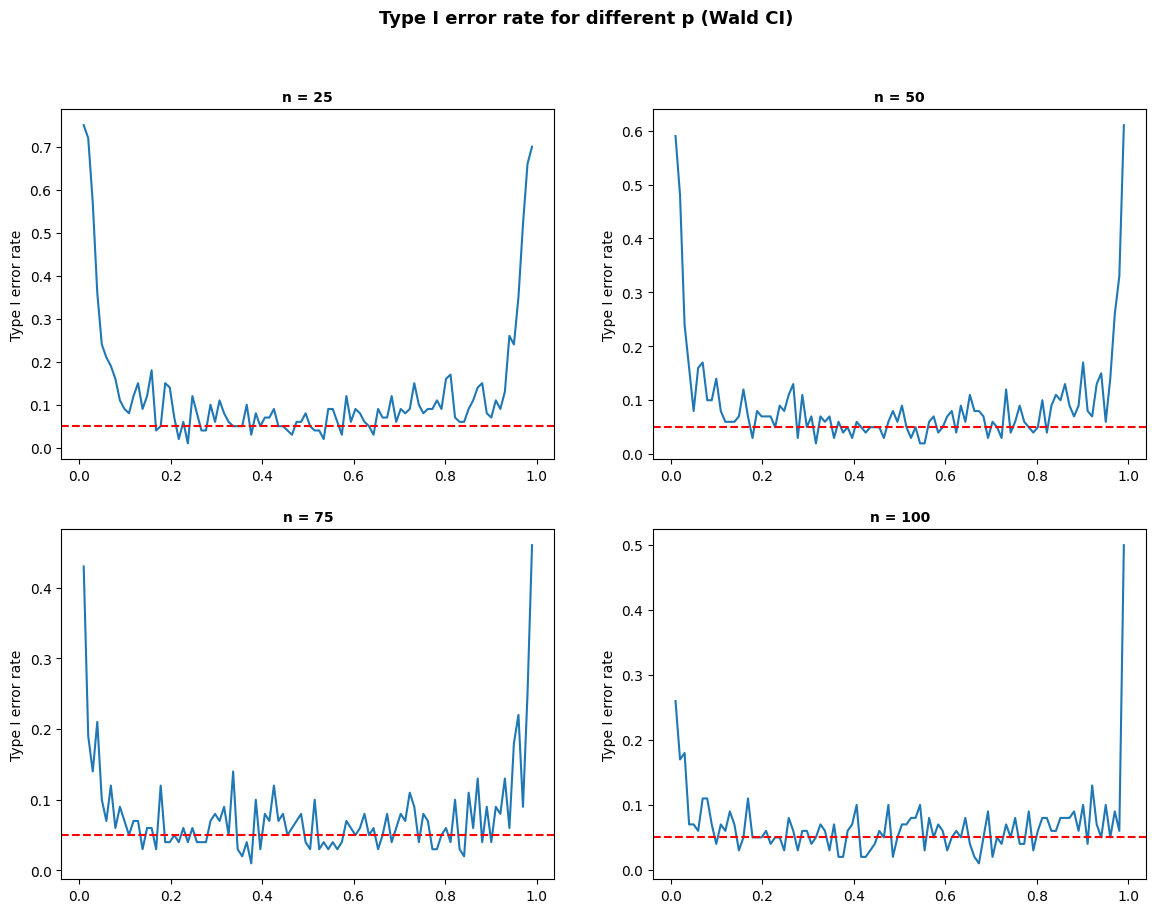

In [4]:
num_obs = [25, 50, 75, 100]
p = np.linspace(0.01, 0.99, 100)

#Visual
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Type I error rate for different p (Wald CI)", fontweight='bold', fontsize=13)
for i in enumerate(num_obs):
    sample_size = i[1]
    proportions = []

    for p_ in p:
        
        result = []
        for num_tests in range(100):
            sample = sc.stats.bernoulli.rvs(p_, size=sample_size) #True proportion = p_

            #Calculation of Wald CI
            mu = sample.mean()
            se = sample.std() / np.sqrt(sample_size)
            alpha = 0.05
            z_critical = sc.stats.norm.ppf(1 - alpha / 2) #Z-critival value f
            ci = [mu - z_critical * se, mu + z_critical * se]

            #H_0 = p_
            reject = 1 if (ci[0] > p_ or ci[1] < p_) else 0
            result.append(reject)
    
        #Type I error rate
        result = np.array(result)
        proportions.append(result.mean())
    
    cell_row, cell_col = i[0] // 2, i[0] % 2
    cur_ax = ax[cell_row][cell_col]
    cur_ax.plot(p, proportions)
    cur_ax.set_title(f"n = {sample_size}", fontweight='bold', fontsize=10)
    cur_ax.set_ylabel("Type I error rate")
    cur_ax.axhline(y=0.05, color="red", linestyle='--')

#Should be symmetrical for x=0.5, because var^2 = p * (1 - p). Need more simulations!!!

Nominal error for Wald CI is systematically higher than 5%. We can use Wilson Interval(Score Interval) to address the issue with 0 and get better results

To address the problem with 0, let's solve a bit more difficult equation. Instead of
$$
\mathrm{P}(-\mathrm{Z}_{1-\alpha/2} \le \frac{\widehat{p}-p}{\sqrt{p(1-p)/n}}\le\mathrm{Z}_{1-\alpha/2})=1-\alpha
$$
Let's solve
$$
\left| \frac{\widehat{p}-p}{\sqrt{p(1-p)/n}} \right|\le\mathrm{Z}
$$
Square the expression to get rid of absolute value
$$
(\widehat{p}-p)^2\le\mathrm{Z}^2\cdot \frac{p(1-p)}{n}
$$
We can rewrite this expression to the following form:
$$
p^2(1+\frac{\mathrm{Z}^2}{n})-p(2\widehat{p}+\frac{\widehat{Z}^2}{n})+\widehat{p}^2\le0
$$
Solve this quadratic equation by using discriminant
$$
\frac{1}{1+\frac{\mathrm{Z}^2}{n}}\cdot(\widehat{p}+\frac{\mathrm{Z}^2}{2n})\pm\frac{Z}{1+\frac{\mathrm{Z}^2}{n}}\cdot\sqrt{\frac{\widehat{p}(1-\widehat{p})}{n}+\frac{\mathrm{Z^2}}{4n}}
$$
by substituting u as 
$$
u=\frac{1}{1+\frac{\mathrm{Z}^2}{n}}
$$
We finally get
$$
u\cdot\widehat{p}+(1-u)\cdot\frac{1}{2}\pm\mathrm{Z}\cdot u\cdot\sqrt{\frac{\widehat{p}(1-\widehat{p})}{n} +(1-u)\cdot\frac{1}{4un} }
$$
The center of interval is a weighted average of p and 0.5

In [5]:
import numpy as np
from scipy import stats

def score_interval(x: np.ndarray, alpha: float) -> tuple:
    n = len(x) #sample size
    p_hat = x.mean()
    z = stats.norm.ppf(1 - alpha / 2) #Quantile

    u = 1 / (1 + z**2 / n)
    center = u * p_hat + (1 - u) * 0.5

    radius = z * u * np.sqrt(p_hat * (1 - p_hat) / n + (1 - u) / (4 * u * n))
    return (center - radius, center + radius)

def wald_interval(sample : np.ndarray, alpha: float) -> tuple:
    mu = sample.mean()
    se = sample.std() / np.sqrt(sample_size)
    alpha = 0.05
    z_critical = sc.stats.norm.ppf(1 - alpha / 2)
    return (mu - z_critical * se, mu + z_critical * se)

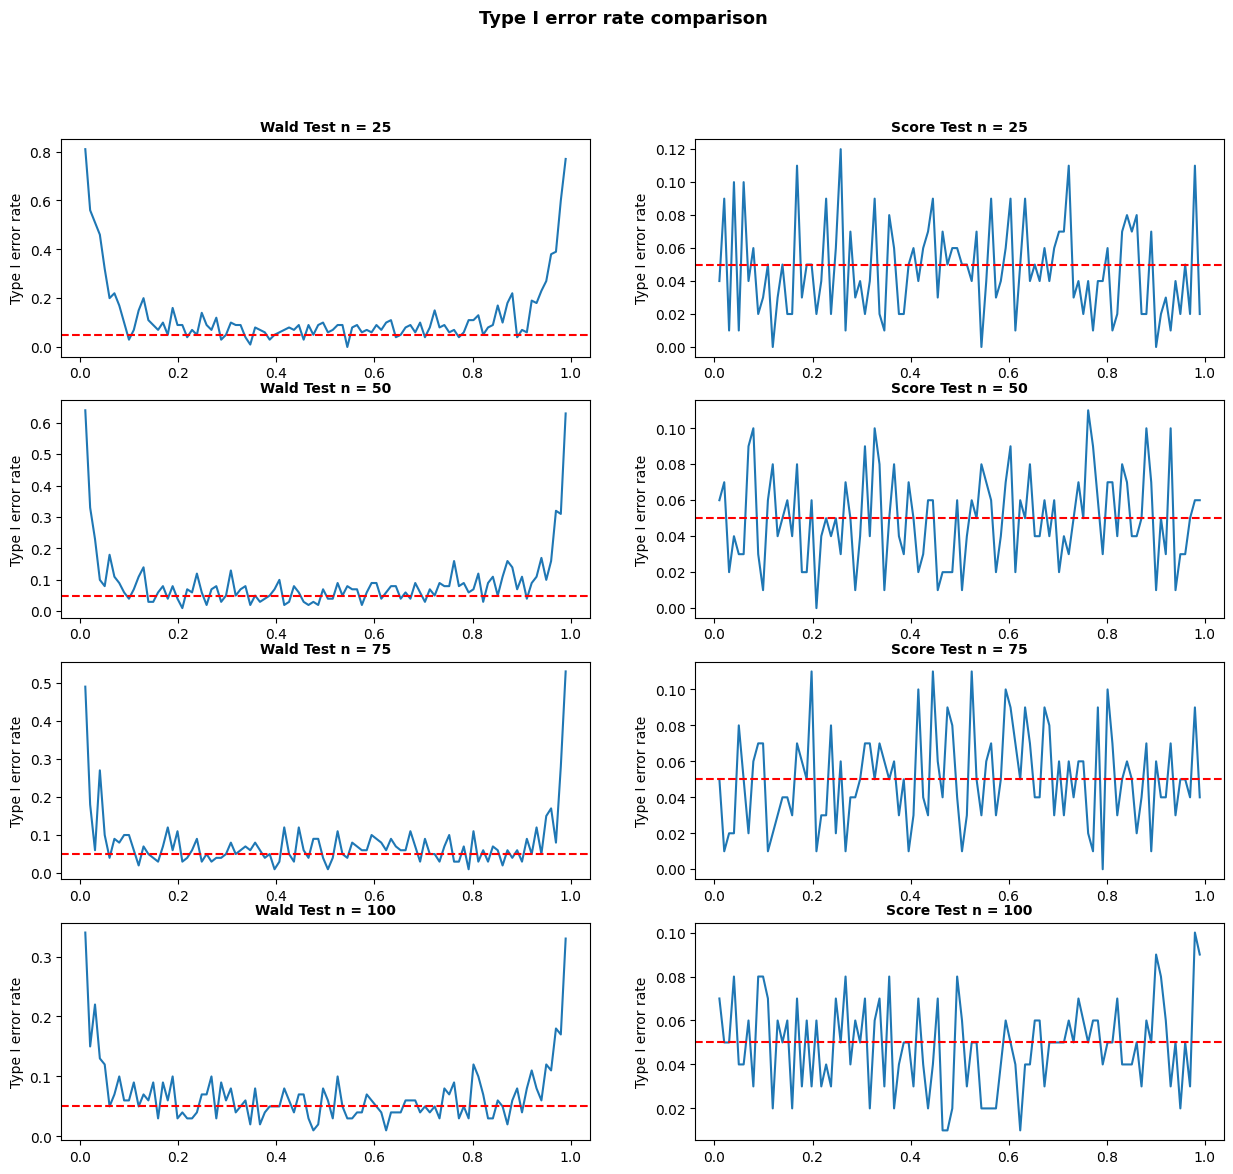

In [6]:
num_obs = [25, 50, 75, 100]
p = np.linspace(0.01, 0.99, 100)

#Visual
fig, ax = plt.subplots(4, 2, figsize=(15, 13))
fig.suptitle("Type I error rate comparison", fontweight='bold', fontsize=13)
for i in enumerate(num_obs):
    sample_size = i[1]
    proportions_wald, proportions_score = [], []

    for p_ in p:
        
        result = []
        for num_tests in range(100):
            sample = sc.stats.bernoulli.rvs(p_, size=sample_size) #True proportion = p_

            #Calculation of CI
            ci_wald = wald_interval(sample, 0.05)
            ci_score = score_interval(sample, 0.05)

            #H_0 = p_
            reject = lambda prob, ci : 1 if (ci[0] > prob or ci[1] < prob) else 0
            #reject = 1 if (ci[0] > p_ or ci[1] < p_) else 0
            result.append(reject(p_, ci_wald))
            result.append(reject(p_, ci_score))
    
        #Type I error rate
        result = np.array(result)
        proportions_wald.append(result[0::2].mean())
        proportions_score.append(result[1::2].mean())
    
    cell_row, cell_col = i[0], 0
    cur_ax = ax[cell_row][cell_col]
    cur_ax.plot(p, proportions_wald)
    cur_ax.set_title(f"Wald Test n = {sample_size}", fontweight='bold', fontsize=10)
    cur_ax.set_ylabel("Type I error rate")
    cur_ax.axhline(y=0.05, color="red", linestyle='--')

    cell_row, cell_col = i[0], 1
    cur_ax = ax[cell_row][cell_col]
    cur_ax.plot(p, proportions_score)
    cur_ax.set_title(f"Score Test n = {sample_size}", fontweight='bold', fontsize=10)
    cur_ax.set_ylabel("Type I error rate")
    cur_ax.axhline(y=0.05, color="red", linestyle='--')


In [7]:
sample = np.array(np.zeros(1000))
print(score_interval(sample, 0.05))
print(wald_interval(sample, 0.05))

(3.686287386450715e-18, 0.003826758485555134)
(0.0, 0.0)


Wilson cannot collapse to a single point